In [1]:
import numpy as np

In [2]:
import numpy as np

# ============================================================
# Aether Crystal Manual Trading Simulator
# ============================================================

S0 = 50.0
SIGMA = 2.51

TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY

CONTRACT_SIZE = 3000


def weeks_to_years(weeks: float) -> float:
    return (weeks * 5) / TRADING_DAYS_PER_YEAR


def steps_for_weeks(weeks: float) -> int:
    return int(round(weeks * 5 * STEPS_PER_DAY))


STEPS_2W = steps_for_weeks(2)  # 40
STEPS_3W = steps_for_weeks(3)  # 60


# ============================================================
# Market bid/ask quotes from screenshot
# IMPORTANT:
# - These are the execution prices.
# - The rightmost cosmetic "PRICE" column is ignored.
# ============================================================

MARKET = {
    "AC": {"bid": 49.975, "ask": 50.025, "limit": 200},
    "AC_50_P": {"bid": 12.00, "ask": 12.05, "limit": 50},
    "AC_50_C": {"bid": 12.00, "ask": 12.05, "limit": 50},
    "AC_35_P": {"bid": 4.33, "ask": 4.35, "limit": 50},
    "AC_40_P": {"bid": 6.50, "ask": 6.55, "limit": 50},
    "AC_45_P": {"bid": 9.05, "ask": 9.10, "limit": 50},
    "AC_60_C": {"bid": 8.80, "ask": 8.85, "limit": 50},
    "AC_50_P_2": {"bid": 9.70, "ask": 9.75, "limit": 50},
    "AC_50_C_2": {"bid": 9.70, "ask": 9.75, "limit": 50},
    "AC_50_CO": {"bid": 22.20, "ask": 22.30, "limit": 50},
    "AC_40_BP": {"bid": 5.00, "ask": 5.10, "limit": 50},
    "AC_45_KO": {"bid": 0.15, "ask": 0.175, "limit": 500},
}


# ============================================================
# Simulate GBM paths
# ============================================================


def simulate_ac_paths(n_paths: int):
    """
    Simulates AETHER_CRYSTAL paths under GBM with fresh randomness every run.

    dS/S = sigma dW

    Exact log update:
        log(S_{t+dt}/S_t)
        = -0.5 * sigma^2 * dt + sigma * sqrt(dt) * Z
    """
    rng = np.random.default_rng()
    dt = 1 / STEPS_PER_YEAR

    z = rng.standard_normal((n_paths, STEPS_3W))
    log_returns = (-0.5 * SIGMA**2 * dt) + SIGMA * np.sqrt(dt) * z

    log_paths = np.cumsum(log_returns, axis=1)
    paths = S0 * np.exp(log_paths)

    # Include initial price at t = 0.
    paths = np.column_stack([np.full(n_paths, S0), paths])
    return paths


# ============================================================
# Payoff functions
# ============================================================


def option_payoffs(paths):
    """
    Returns terminal payoff / terminal value per one contract.

    For options:
        payoff is option payoff.

    For AC:
        payoff is terminal stock value S_T.
        The execution price is subtracted later in portfolio_pnl_per_path().
    """
    S_2W = paths[:, STEPS_2W]
    S_3W = paths[:, STEPS_3W]

    # Chooser:
    # At 2 weeks, choose call if S_2W > 50, otherwise choose put.
    chooser_is_call = S_2W > 50
    chooser_payoff = np.where(
        chooser_is_call,
        np.maximum(S_3W - 50, 0),
        np.maximum(50 - S_3W, 0),
    )

    # KO put:
    # Strike = 45, barrier = 35, expiry = 3 weeks.
    # Barrier is checked only at discrete simulated points.
    hit_barrier = np.min(paths[:, 1 : STEPS_3W + 1], axis=1) < 35
    ko_payoff = np.where(
        hit_barrier,
        0,
        np.maximum(45 - S_3W, 0),
    )

    return {
        # Underlying
        "AC": S_3W,
        # 3-week vanilla options
        "AC_50_C": np.maximum(S_3W - 50, 0),
        "AC_50_P": np.maximum(50 - S_3W, 0),
        "AC_60_C": np.maximum(S_3W - 60, 0),
        "AC_35_P": np.maximum(35 - S_3W, 0),
        "AC_40_P": np.maximum(40 - S_3W, 0),
        "AC_45_P": np.maximum(45 - S_3W, 0),
        # 2-week vanilla options
        "AC_50_C_2": np.maximum(S_2W - 50, 0),
        "AC_50_P_2": np.maximum(50 - S_2W, 0),
        # Exotics
        "AC_50_CO": chooser_payoff,
        "AC_40_BP": np.where(S_3W < 40, 10, 0),
        "AC_45_KO": ko_payoff,
    }


# ============================================================
# Portfolio PnL
# ============================================================


def validate_positions(positions):
    """
    Checks whether positions respect displayed volume limits.
    Positive qty = buy.
    Negative qty = sell.
    """
    for product, qty in positions.items():
        if product not in MARKET:
            raise ValueError(f"Missing market quote for product: {product}")

        limit = MARKET[product]["limit"]
        if abs(qty) > limit:
            raise ValueError(
                f"Position limit exceeded for {product}: "
                f"qty={qty}, limit={limit}"
            )


def portfolio_pnl_per_path(paths, positions):
    """
    Computes PnL per simulated path.

    Positive qty:
        buy at ask, payoff at expiry.
        PnL = qty * (payoff - ask)

    Negative qty:
        sell/short at bid, pay payoff at expiry.
        PnL = qty * (payoff - bid)

    Since qty is negative for shorts:
        qty * (payoff - bid) = |qty| * (bid - payoff)

    Final result is multiplied by CONTRACT_SIZE.
    """
    validate_positions(positions)

    payoffs = option_payoffs(paths)
    pnl = np.zeros(paths.shape[0])

    for product, qty in positions.items():
        if qty == 0:
            continue

        if product not in payoffs:
            raise ValueError(f"Unknown payoff product: {product}")

        if qty > 0:
            execution_price = MARKET[product]["ask"]
        else:
            execution_price = MARKET[product]["bid"]

        pnl += qty * (payoffs[product] - execution_price)

    return pnl * CONTRACT_SIZE


def estimate_official_score(
    positions,
    n_paths_per_score=100,
    n_repeats=10000,
):
    """
    Repeats the official scoring process many times.

    Official-like process:
        1. Simulate 100 paths.
        2. Compute portfolio PnL on each path.
        3. Average the 100 path PnLs.
        4. That average is one possible official score.

    Repeating this many times estimates:
        - expected official score
        - score volatility
        - downside percentiles
    """
    scores = []

    for _ in range(n_repeats):
        paths = simulate_ac_paths(n_paths=n_paths_per_score)
        pnl_paths = portfolio_pnl_per_path(paths, positions)
        scores.append(np.mean(pnl_paths))

    scores = np.array(scores)

    summary = {
        "mean_score": np.mean(scores),
        "std_score": np.std(scores),
        "p01": np.percentile(scores, 1),
        "p05": np.percentile(scores, 5),
        "p25": np.percentile(scores, 25),
        "median": np.percentile(scores, 50),
        "p75": np.percentile(scores, 75),
        "p95": np.percentile(scores, 95),
        "p99": np.percentile(scores, 99),
        "prob_negative": np.mean(scores < 0),
    }

    return summary, scores


def estimate_fair_values(n_paths=500000):
    """
    Estimates fair payoff values of each product using many paths.
    This is useful for checking whether each product is cheap/rich
    relative to bid/ask.
    """
    paths = simulate_ac_paths(n_paths)
    payoffs = option_payoffs(paths)

    rows = []
    for product, payoff in payoffs.items():
        if product not in MARKET:
            continue

        fair = np.mean(payoff)
        bid = MARKET[product]["bid"]
        ask = MARKET[product]["ask"]

        buy_edge = fair - ask
        sell_edge = bid - fair

        rows.append(
            {
                "product": product,
                "fair": fair,
                "bid": bid,
                "ask": ask,
                "buy_edge": buy_edge,
                "sell_edge": sell_edge,
            }
        )

    rows = sorted(rows, key=lambda x: x["product"])
    return rows


def print_summary(name, positions, n_paths_per_score=100, n_repeats=10000):
    """
    Convenience wrapper to print portfolio and score summary.
    """
    summary, scores = estimate_official_score(
        positions,
        n_paths_per_score=n_paths_per_score,
        n_repeats=n_repeats,
    )

    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Positions:")
    for product, qty in positions.items():
        if qty != 0:
            side = "BUY" if qty > 0 else "SELL"
            print(f"{product:12s} {side:4s} {abs(qty):4d}")

    print()
    print("Score summary:")
    for k, v in summary.items():
        print(f"{k:>15}: {v:,.2f}")

    return summary, scores

In [32]:
positions = {
    "AC": 0,
    # Vanilla options
    "AC_50_P": 0,
    "AC_50_C": 30,
    "AC_35_P": 0,
    "AC_40_P": 0,
    "AC_45_P": 45,
    "AC_60_C": 0,
    # 2-week options
    "AC_50_P_2": 50,
    "AC_50_C_2": 40,
    # Exotics
    "AC_45_KO": 500,
    "AC_40_BP": -50,
    "AC_50_CO": -50,
}

# grid search result
# positions = {
#     "AC": 0,
#     "AC_50_P": 0,
#     "AC_50_C": 30,
#     "AC_35_P": 0,
#     "AC_40_P": 0,
#     "AC_45_P": 50,
#     "AC_60_C": 0,
#     "AC_50_P_2": 50,
#     "AC_50_C_2": 35,
#     "AC_45_KO": 500,
#     "AC_40_BP": -50,
#     "AC_50_CO": -50,
# }

In [33]:
# ============================================================
# Run analysis
# ============================================================

if __name__ == "__main__":
    # 1. Estimate fair values of all products.
    print("=" * 70)
    print("Estimated fair values")
    print("=" * 70)

    fair_rows = estimate_fair_values(n_paths=300000)

    # print(
    #     f"{'product':12s} "
    #     f"{'fair':>10s} "
    #     f"{'bid':>8s} "
    #     f"{'ask':>8s} "
    #     f"{'buy_edge':>10s} "
    #     f"{'sell_edge':>10s}"
    # )

    # for r in fair_rows:
    #     print(
    #         f"{r['product']:12s} "
    #         f"{r['fair']:10.4f} "
    #         f"{r['bid']:8.4f} "
    #         f"{r['ask']:8.4f} "
    #         f"{r['buy_edge']:10.4f} "
    #         f"{r['sell_edge']:10.4f}"
    #     )

    print()

    # 2. Score candidate portfolios.
    print_summary(
        "Teammate proposed portfolio",
        positions,
        n_paths_per_score=100,
        n_repeats=10000,
    )

Estimated fair values

Teammate proposed portfolio
Positions:
AC_50_C      BUY    30
AC_45_P      BUY    45
AC_50_P_2    BUY    50
AC_50_C_2    BUY    40
AC_45_KO     BUY   500
AC_40_BP     SELL   50
AC_50_CO     SELL   50

Score summary:
     mean_score: 159,034.56
      std_score: 240,004.91
            p01: -371,890.56
            p05: -224,365.86
            p25: -5,950.27
         median: 154,007.92
            p75: 320,399.69
            p95: 564,244.11
            p99: 738,244.99
  prob_negative: 0.26


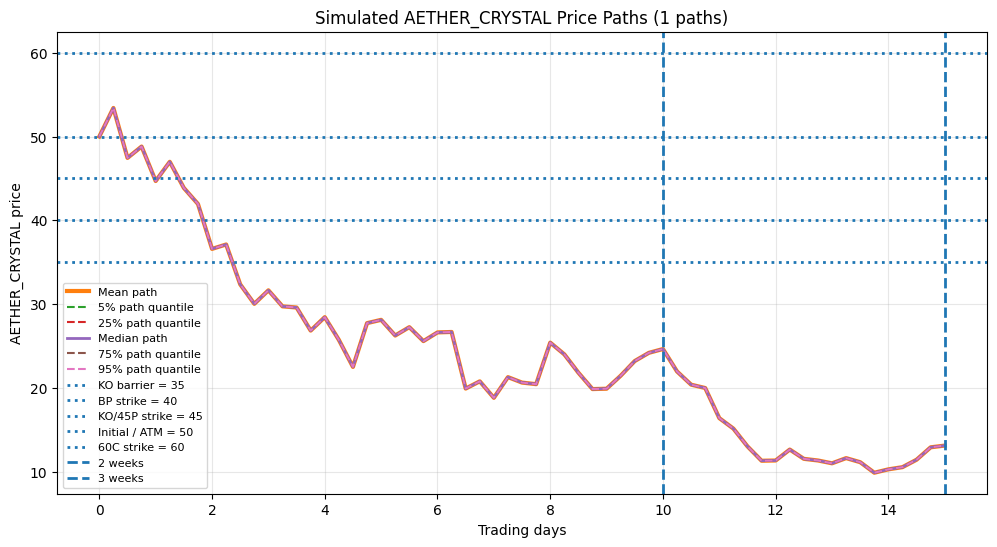

array([[50.        , 53.41056852, 47.44997293, 48.80869589, 44.69558938,
        46.98794994, 43.86729168, 41.95763481, 36.59844289, 37.12444736,
        32.36433783, 30.04378797, 31.65625307, 29.7425478 , 29.6039784 ,
        26.85026617, 28.45548818, 25.74152542, 22.51773704, 27.74004465,
        28.13386656, 26.26366757, 27.26258241, 25.59664804, 26.6354304 ,
        26.68686811, 19.93514269, 20.798721  , 18.82879666, 21.30054366,
        20.6488932 , 20.46026789, 25.41749726, 24.01954397, 21.82612316,
        19.8753875 , 19.91802364, 21.46696199, 23.22261509, 24.19874784,
        24.65138803, 21.974092  , 20.40151276, 20.00006788, 16.40871298,
        15.1576857 , 13.03611305, 11.32612406, 11.3551813 , 12.66036941,
        11.55239956, 11.35696659, 11.01943713, 11.6400896 , 11.15150382,
         9.89675872, 10.29986044, 10.56196034, 11.44889106, 12.92975814,
        13.1333522 ]])

In [5]:
# import matplotlib.pyplot as plt
# import numpy as np


# def plot_ac_price_paths(
#     n_paths=100,
#     show_mean=True,
#     show_quantiles=True,
#     log_scale=False,
# ):
#     """
#     Plot simulated AETHER_CRYSTAL price paths.

#     n_paths=100 matches the official number of simulations.
#     """
#     paths = simulate_ac_paths(n_paths)

#     # Convert steps to trading days
#     t = np.arange(paths.shape[1]) / STEPS_PER_DAY

#     plt.figure(figsize=(12, 6))

#     # Plot individual paths
#     for i in range(n_paths):
#         plt.plot(t, paths[i], alpha=0.25, linewidth=1)

#     # Mean path
#     if show_mean:
#         mean_path = paths.mean(axis=0)
#         plt.plot(t, mean_path, linewidth=3, label="Mean path")

#     # Quantile bands
#     if show_quantiles:
#         q05 = np.percentile(paths, 5, axis=0)
#         q25 = np.percentile(paths, 25, axis=0)
#         q50 = np.percentile(paths, 50, axis=0)
#         q75 = np.percentile(paths, 75, axis=0)
#         q95 = np.percentile(paths, 95, axis=0)

#         plt.plot(
#             t, q05, linestyle="--", linewidth=1.5, label="5% path quantile"
#         )
#         plt.plot(
#             t, q25, linestyle="--", linewidth=1.5, label="25% path quantile"
#         )
#         plt.plot(t, q50, linestyle="-", linewidth=2, label="Median path")
#         plt.plot(
#             t, q75, linestyle="--", linewidth=1.5, label="75% path quantile"
#         )
#         plt.plot(
#             t, q95, linestyle="--", linewidth=1.5, label="95% path quantile"
#         )

#     # Important levels
#     plt.axhline(35, linestyle=":", linewidth=2, label="KO barrier = 35")
#     plt.axhline(40, linestyle=":", linewidth=2, label="BP strike = 40")
#     plt.axhline(45, linestyle=":", linewidth=2, label="KO/45P strike = 45")
#     plt.axhline(50, linestyle=":", linewidth=2, label="Initial / ATM = 50")
#     plt.axhline(60, linestyle=":", linewidth=2, label="60C strike = 60")

#     # Important times
#     plt.axvline(
#         STEPS_2W / STEPS_PER_DAY, linestyle="--", linewidth=2, label="2 weeks"
#     )
#     plt.axvline(
#         STEPS_3W / STEPS_PER_DAY, linestyle="--", linewidth=2, label="3 weeks"
#     )

#     if log_scale:
#         plt.yscale("log")

#     plt.title(f"Simulated AETHER_CRYSTAL Price Paths ({n_paths} paths)")
#     plt.xlabel("Trading days")
#     plt.ylabel("AETHER_CRYSTAL price")
#     plt.legend(loc="best", fontsize=8)
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     return paths


# # Example: official-like 100 simulated paths
# paths_100 = plot_ac_price_paths(n_paths=1)
# paths_100

In [27]:
# ============================================================
# One-cell portfolio grid search for Aether Crystal manual round
# ============================================================

import itertools
import numpy as np
import pandas as pd

# ============================================================
# 0. Settings
# ============================================================

N_PATHS_PER_SCORE = 100  # official rule: average over 100 paths
N_TRAIN_REPEATS = 3000  # many possible official outcomes for search
N_TEST_REPEATS = 10000  # fresh validation for top portfolios
BATCH_REPEATS = 500  # lower if memory is an issue

RISK_PENALTY = 0.30  # robust objective = mean - RISK_PENALTY * std
LEG_PENALTY = 0.0  # set e.g. 1000 or 3000 to penalize too many legs
TOP_N_TRAIN = 40  # how many train winners to validate

PRODUCTS = [
    "AC",
    "AC_50_P",
    "AC_50_C",
    "AC_35_P",
    "AC_40_P",
    "AC_45_P",
    "AC_60_C",
    "AC_50_P_2",
    "AC_50_C_2",
    "AC_45_KO",
    "AC_40_BP",
    "AC_50_CO",
]

PRODUCT_TO_IDX = {p: i for i, p in enumerate(PRODUCTS)}

BIDS = np.array([MARKET[p]["bid"] for p in PRODUCTS], dtype=float)
ASKS = np.array([MARKET[p]["ask"] for p in PRODUCTS], dtype=float)
LIMITS = np.array([MARKET[p]["limit"] for p in PRODUCTS], dtype=int)


# ============================================================
# 1. Convert positions <-> vectors
# ============================================================


def positions_to_vector(positions):
    q = np.zeros(len(PRODUCTS), dtype=float)
    for product, qty in positions.items():
        if product not in PRODUCT_TO_IDX:
            raise ValueError(f"Unknown product: {product}")
        q[PRODUCT_TO_IDX[product]] = qty
    if np.any(np.abs(q) > LIMITS):
        bad = [
            (PRODUCTS[i], q[i], LIMITS[i])
            for i in range(len(PRODUCTS))
            if abs(q[i]) > LIMITS[i]
        ]
        raise ValueError(f"Position limit exceeded: {bad}")
    return q


def vector_to_positions(q):
    return {p: int(q[i]) for i, p in enumerate(PRODUCTS) if int(q[i]) != 0}


def full_positions_dict(q):
    return {p: int(q[i]) for i, p in enumerate(PRODUCTS)}


# ============================================================
# 2. Simulate official-style average fair values
# ============================================================


def simulate_official_payoff_means(
    n_repeats,
    n_paths_per_score=100,
    batch_repeats=500,
):
    """
    Returns matrix of shape:
        (n_repeats, n_products)

    Each row represents one possible official 100-path fair-value vector.
    """
    all_rows = []
    remaining = n_repeats

    while remaining > 0:
        m = min(batch_repeats, remaining)

        # Simulate m official experiments, each with n_paths_per_score paths.
        paths = simulate_ac_paths(m * n_paths_per_score)
        payoffs = option_payoffs(paths)

        payoff_matrix = np.column_stack([payoffs[p] for p in PRODUCTS])
        payoff_means = payoff_matrix.reshape(
            m,
            n_paths_per_score,
            len(PRODUCTS),
        ).mean(axis=1)

        all_rows.append(payoff_means)
        remaining -= m

    return np.vstack(all_rows)


# ============================================================
# 3. Fast portfolio scoring
# ============================================================


def score_qty_matrix(payoff_means, Q):
    """
    payoff_means: shape (R, P)
    Q: shape (N, P), each row is one portfolio.

    Score formula:
        score = CONTRACT_SIZE * sum_j q_j * (fair_j - execution_price_j)

    execution price:
        ask if q > 0
        bid if q < 0
    """
    Q = np.asarray(Q, dtype=float)

    exec_prices = np.where(Q > 0, ASKS, np.where(Q < 0, BIDS, 0.0))
    execution_cost_term = np.sum(Q * exec_prices, axis=1)

    # scores shape = (R repeats, N portfolios)
    scores = CONTRACT_SIZE * (
        payoff_means @ Q.T - execution_cost_term[None, :]
    )
    return scores


def summarize_scores(scores, Q, risk_penalty=0.30, leg_penalty=0.0):
    """
    scores shape: (R, N)
    Q shape: (N, P)
    """
    mean = scores.mean(axis=0)
    std = scores.std(axis=0)
    p01 = np.percentile(scores, 1, axis=0)
    p05 = np.percentile(scores, 5, axis=0)
    p25 = np.percentile(scores, 25, axis=0)
    median = np.percentile(scores, 50, axis=0)
    p75 = np.percentile(scores, 75, axis=0)
    p95 = np.percentile(scores, 95, axis=0)
    p99 = np.percentile(scores, 99, axis=0)
    prob_negative = (scores < 0).mean(axis=0)

    n_legs = (Q != 0).sum(axis=1)
    gross_qty = np.abs(Q).sum(axis=1)

    robust = mean - risk_penalty * std - leg_penalty * n_legs

    return pd.DataFrame(
        {
            "mean_score": mean,
            "std_score": std,
            "p01": p01,
            "p05": p05,
            "p25": p25,
            "median": median,
            "p75": p75,
            "p95": p95,
            "p99": p99,
            "prob_negative": prob_negative,
            "n_legs": n_legs,
            "gross_qty": gross_qty,
            "robust_score": robust,
        }
    )


# ============================================================
# 4. Build grid
# ============================================================


def build_grid_matrix(grids, fixed_positions=None):
    """
    grids:
        dict product -> list of quantities to test

    fixed_positions:
        dict product -> fixed quantity

    Returns:
        Q matrix shape (n_portfolios, n_products)
    """
    if fixed_positions is None:
        fixed_positions = {}

    grid_products = list(grids.keys())
    grid_values = [grids[p] for p in grid_products]

    base = positions_to_vector(fixed_positions)
    rows = []

    total = np.prod([len(v) for v in grid_values])
    print(f"Building grid with {total:,} portfolios...")

    for combo in itertools.product(*grid_values):
        q = base.copy()

        for product, qty in zip(grid_products, combo):
            q[PRODUCT_TO_IDX[product]] = qty

        if np.all(np.abs(q) <= LIMITS):
            rows.append(q)

    Q = np.vstack(rows)
    print(f"Valid portfolios: {len(Q):,}")
    return Q


# ============================================================
# 5. Evaluate portfolios in batches
# ============================================================


def evaluate_grid(
    Q,
    payoff_means,
    risk_penalty=0.30,
    leg_penalty=0.0,
    objective="robust_score",
    batch_size=5000,
):
    """
    Scores all portfolios without storing a huge scores matrix at once.
    """
    dfs = []

    n = len(Q)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        Q_batch = Q[start:end]

        scores = score_qty_matrix(payoff_means, Q_batch)
        df_batch = summarize_scores(
            scores,
            Q_batch,
            risk_penalty=risk_penalty,
            leg_penalty=leg_penalty,
        )

        df_batch["portfolio_id"] = np.arange(start, end)
        dfs.append(df_batch)

        print(f"Evaluated {end:,}/{n:,}")

    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values(objective, ascending=False).reset_index(drop=True)

    return df


def attach_positions(df, Q):
    df = df.copy()
    df["positions"] = df["portfolio_id"].apply(
        lambda i: vector_to_positions(Q[int(i)])
    )
    for p in PRODUCTS:
        idx = PRODUCT_TO_IDX[p]
        df[p] = df["portfolio_id"].apply(lambda i: int(Q[int(i), idx]))
    return df


# ============================================================
# 6. Controlled search grids
# ============================================================
# This grid is intentionally not "everything at every level."
# It searches around the positive-EV / hedged structures we discussed,
# while avoiding obvious overhedge explosion.

fixed_positions = {
    "AC": 0,
}

grids = {
    # Core exotic edges
    "AC_45_KO": [300, 400, 500],
    "AC_40_BP": [-50, -25, 0],
    "AC_50_CO": [-50, -25, 0],
    # 2-week convexity
    "AC_50_P_2": [25, 40, 50],
    "AC_50_C_2": [20, 35, 50],
    # Targeted hedges / chooser hedge
    "AC_50_C": [0, 15, 30, 45, 50],
    "AC_45_P": [20, 35, 45, 50],
    "AC_50_P": [0, 10, 20, 30],
    # Usually avoid these, but allow small tests
    "AC_35_P": [0, 10],
    "AC_40_P": [0, 20],
    "AC_60_C": [0, 25],
}


# ============================================================
# 7. Train search
# ============================================================

print("=" * 80)
print("TRAIN: simulate possible official fair values")
print("=" * 80)

train_payoff_means = simulate_official_payoff_means(
    n_repeats=N_TRAIN_REPEATS,
    n_paths_per_score=N_PATHS_PER_SCORE,
    batch_repeats=BATCH_REPEATS,
)

Q = build_grid_matrix(grids, fixed_positions=fixed_positions)

print("=" * 80)
print("TRAIN: evaluate grid")
print("=" * 80)

train_df = evaluate_grid(
    Q,
    train_payoff_means,
    risk_penalty=RISK_PENALTY,
    leg_penalty=LEG_PENALTY,
    objective="robust_score",
    batch_size=5000,
)

train_df = attach_positions(train_df, Q)

print("=" * 80)
print("Top train portfolios")
print("=" * 80)

display_cols = [
    "mean_score",
    "std_score",
    "p05",
    "prob_negative",
    "robust_score",
    "n_legs",
    "gross_qty",
    "positions",
]

display(train_df[display_cols].head(TOP_N_TRAIN))


# ============================================================
# 8. Out-of-sample validation on top train portfolios
# ============================================================

print("=" * 80)
print("TEST: fresh validation of top train portfolios")
print("=" * 80)

top_ids = train_df.head(TOP_N_TRAIN)["portfolio_id"].to_numpy(dtype=int)
Q_top = Q[top_ids]

test_payoff_means = simulate_official_payoff_means(
    n_repeats=N_TEST_REPEATS,
    n_paths_per_score=N_PATHS_PER_SCORE,
    batch_repeats=BATCH_REPEATS,
)

test_scores = score_qty_matrix(test_payoff_means, Q_top)
test_df = summarize_scores(
    test_scores,
    Q_top,
    risk_penalty=RISK_PENALTY,
    leg_penalty=LEG_PENALTY,
)

test_df["train_rank"] = np.arange(1, len(Q_top) + 1)
test_df["positions"] = [vector_to_positions(q) for q in Q_top]

for p in PRODUCTS:
    idx = PRODUCT_TO_IDX[p]
    test_df[p] = Q_top[:, idx].astype(int)

test_df = test_df.sort_values("robust_score", ascending=False).reset_index(
    drop=True
)

print("=" * 80)
print("Top validated portfolios")
print("=" * 80)

display(
    test_df[
        [
            "train_rank",
            "mean_score",
            "std_score",
            "p05",
            "prob_negative",
            "robust_score",
            "n_legs",
            "gross_qty",
            "positions",
        ]
    ].head(20)
)


# ============================================================
# 9. Print recommended final portfolio
# ============================================================

best = test_df.iloc[0]
best_positions = best["positions"]

print("=" * 80)
print("Recommended final portfolio")
print("=" * 80)

for product in PRODUCTS:
    qty = best_positions.get(product, 0)
    if qty == 0:
        continue
    side = "BUY" if qty > 0 else "SELL"
    print(f"{product:12s} {side:4s} {abs(qty):4d}")

print()
print("Validation summary:")
for k in [
    "mean_score",
    "std_score",
    "p05",
    "prob_negative",
    "robust_score",
    "n_legs",
    "gross_qty",
]:
    print(f"{k:>15}: {best[k]:,.2f}")

print()
print("Copy-paste positions:")
print("positions = {")
for product in PRODUCTS:
    qty = int(best_positions.get(product, 0))
    print(f'    "{product}": {qty},')
print("}")

TRAIN: simulate possible official fair values
Building grid with 155,520 portfolios...
Valid portfolios: 155,520
TRAIN: evaluate grid
Evaluated 5,000/155,520
Evaluated 10,000/155,520
Evaluated 15,000/155,520
Evaluated 20,000/155,520
Evaluated 25,000/155,520
Evaluated 30,000/155,520
Evaluated 35,000/155,520
Evaluated 40,000/155,520
Evaluated 45,000/155,520
Evaluated 50,000/155,520
Evaluated 55,000/155,520
Evaluated 60,000/155,520
Evaluated 65,000/155,520
Evaluated 70,000/155,520
Evaluated 75,000/155,520
Evaluated 80,000/155,520
Evaluated 85,000/155,520
Evaluated 90,000/155,520
Evaluated 95,000/155,520
Evaluated 100,000/155,520
Evaluated 105,000/155,520
Evaluated 110,000/155,520
Evaluated 115,000/155,520
Evaluated 120,000/155,520
Evaluated 125,000/155,520
Evaluated 130,000/155,520
Evaluated 135,000/155,520
Evaluated 140,000/155,520
Evaluated 145,000/155,520
Evaluated 150,000/155,520
Evaluated 155,000/155,520
Evaluated 155,520/155,520
Top train portfolios


,mean_score,std_score,p05,prob_negative,robust_score,n_legs,gross_qty,positions
0,145423.002311,199749.110746,-170017.089908,0.248333,85498.269087,7,765.0,"{'AC_50_C': 45, 'AC_45_P': 50, 'AC_50_P_2': 50..."
1,145134.800815,199688.349902,-171753.241872,0.244000,85228.295845,8,770.0,"{'AC_50_P': 10, 'AC_50_C': 45, 'AC_45_P': 45, ..."
2,145223.556710,200706.560332,-171475.491692,0.245667,85011.588610,8,775.0,"{'AC_50_C': 45, 'AC_35_P': 10, 'AC_45_P': 50, ..."
3,145378.275803,201232.111558,-171415.002366,0.247000,85008.642335,7,760.0,"{'AC_50_C': 45, 'AC_45_P': 45, 'AC_50_P_2': 50..."
4,145178.830201,200591.125633,-170847.551485,0.248333,85001.492511,8,770.0,"{'AC_50_C': 45, 'AC_35_P': 10, 'AC_45_P': 45, ..."
5,145045.347799,200514.345518,-169210.990151,0.247333,84891.044143,8,760.0,"{'AC_50_P': 10, 'AC_50_C': 45, 'AC_45_P': 35, ..."
6,145179.527324,201239.808893,-176545.077446,0.244333,84807.584656,8,775.0,"{'AC_50_P': 10, 'AC_50_C': 45, 'AC_45_P': 50, ..."
7,144801.872811,200059.148145,-169706.547595,0.244000,84784.128368,8,770.0,"{'AC_50_P': 20, 'AC_50_C': 45, 'AC_45_P': 35, ..."
8,144845.902197,200267.156510,-171699.094819,0.247000,84765.755244,9,770.0,"{'AC_50_P': 10, 'AC_50_C': 45, 'AC_35_P': 10, ..."
9,144424.218299,199608.548815,-169000.460490,0.246667,84541.653655,8,765.0,"{'AC_50_P': 30, 'AC_50_C': 45, 'AC_45_P': 20, ..."


TEST: fresh validation of top train portfolios
Top validated portfolios


,train_rank,mean_score,std_score,p05,prob_negative,robust_score,n_legs,gross_qty,positions
0,16,159474.141967,231528.857296,-207668.789051,0.2507,90015.484779,7,765.0,"{'AC_50_C': 30, 'AC_45_P': 50, 'AC_50_P_2': 50..."
1,19,159604.009846,232422.452453,-208614.683792,0.2513,89877.274110,7,760.0,"{'AC_50_C': 30, 'AC_45_P': 45, 'AC_50_P_2': 50..."
2,28,159280.903723,232238.206606,-208772.922886,0.2521,89609.441742,8,760.0,"{'AC_50_P': 10, 'AC_50_C': 30, 'AC_45_P': 35, ..."
3,25,159234.854708,232162.959112,-211278.307353,0.2507,89585.966974,8,770.0,"{'AC_50_C': 30, 'AC_35_P': 10, 'AC_45_P': 45, ..."
4,34,159021.167965,232295.781417,-212751.482985,0.2540,89332.433540,8,770.0,"{'AC_50_P': 10, 'AC_50_C': 30, 'AC_45_P': 45, ..."
5,31,159104.986828,232636.363305,-213991.099036,0.2540,89314.077837,8,775.0,"{'AC_50_C': 30, 'AC_35_P': 10, 'AC_45_P': 50, ..."
6,40,158911.748585,232324.511086,-212139.154413,0.2528,89214.395259,9,770.0,"{'AC_50_P': 10, 'AC_50_C': 30, 'AC_35_P': 10, ..."
7,1,149832.631469,207315.927030,-178934.286684,0.2413,87637.853360,7,765.0,"{'AC_50_C': 45, 'AC_45_P': 50, 'AC_50_P_2': 50..."
8,2,149379.657467,206731.852481,-176106.393134,0.2410,87360.101723,8,770.0,"{'AC_50_P': 10, 'AC_50_C': 45, 'AC_45_P': 45, ..."
9,4,149962.499348,209063.902885,-181587.550653,0.2448,87243.328483,7,760.0,"{'AC_50_C': 45, 'AC_45_P': 45, 'AC_50_P_2': 50..."


Recommended final portfolio
AC_50_C      BUY    30
AC_45_P      BUY    50
AC_50_P_2    BUY    50
AC_50_C_2    BUY    35
AC_45_KO     BUY   500
AC_40_BP     SELL   50
AC_50_CO     SELL   50

Validation summary:
     mean_score: 159,474.14
      std_score: 231,528.86
            p05: -207,668.79
  prob_negative: 0.25
   robust_score: 90,015.48
         n_legs: 7.00
      gross_qty: 765.00

Copy-paste positions:
positions = {
    "AC": 0,
    "AC_50_P": 0,
    "AC_50_C": 30,
    "AC_35_P": 0,
    "AC_40_P": 0,
    "AC_45_P": 50,
    "AC_60_C": 0,
    "AC_50_P_2": 50,
    "AC_50_C_2": 35,
    "AC_45_KO": 500,
    "AC_40_BP": -50,
    "AC_50_CO": -50,
}
